<a href="https://colab.research.google.com/github/dagmaros27/AIMS_Notebooks/blob/main/ABC_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCMC vs ABC
In this exercise, we will learn the basics of the Approximate Bayesian Computation technique.

We will create a toy model and analyze the convergence of the algorithm.
The goal is to measure the parameter of a given model using some observed data.

* The observed data are in file "observed_data.txt"


* The data was generated by the following forward process:
    * 100 samples were drawn from a Gaussian Distribution with parameters mean $\mu$ and standard deviation $\sigma$
    * $\mu$ is unknown, but $\sigma$ is given, $\sigma$=10.
    
    
We will first run an MCMC and then use the ABC technique for this toy case.

In [3]:
import matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import norm

In [4]:
toy_data=np.loadtxt('toy_data.txt')
print(toy_data.shape)
N=toy_data.shape[0]

(100,)


Size of the data array = 100


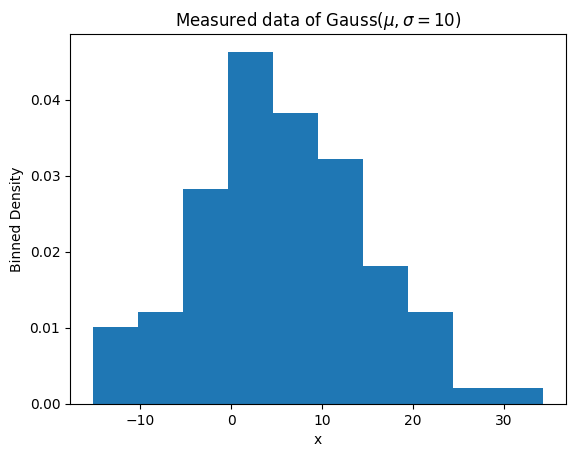

In [5]:
# Plot the data
sigma = 10
print('Size of the data array = {}'.format(np.size(toy_data)))
plt.title(r"Measured data of Gauss$(\mu,\sigma=10)$")
plt.hist(toy_data,bins=10, density=True)
plt.xlabel('x')
plt.ylabel('Binned Density')
plt.show()

In [6]:
np.mean(toy_data)

np.float64(5.553942704864362)

In [7]:
# Define the Gaussian function
def Gauss(x, mu):
    sigma=10 #sigma is known
    y = (2*np.pi*sigma**2)**(-1/2.)*np.exp(-(x-mu)**2/2/sigma**2)
    return y

In [8]:
y_data, bin_edges = np.histogram(toy_data,bins=10, density=True)
bin_centers = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])/2.

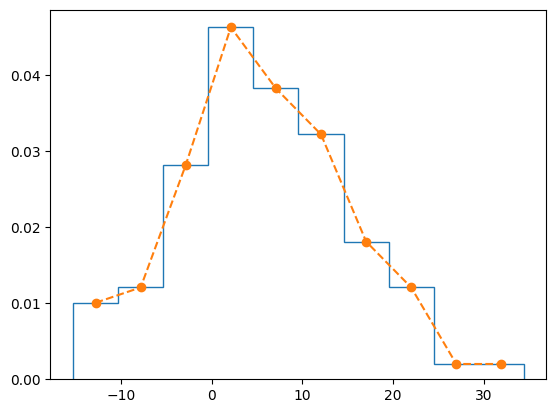

In [9]:
plt.hist(toy_data,bins=10, density=True, histtype='step')
plt.plot(bin_centers,y_data, marker='o',linestyle='--')
plt.show()

In [10]:
# first thing to do would be just a fit of the histogram
mu_fit, mu_fit_error = curve_fit(Gauss,bin_centers,y_data)
print(mu_fit, mu_fit_error)

[5.18268919] [[0.44664313]]


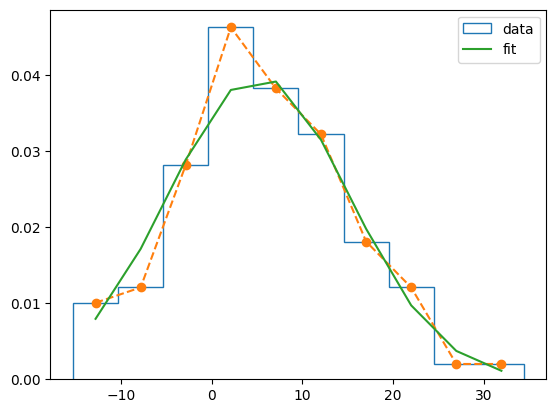

In [11]:
plt.hist(toy_data,bins=10, density=True, histtype='step',label='data')
plt.plot(bin_centers,y_data, marker='o',linestyle='--')
plt.plot(bin_centers, Gauss(bin_centers,mu_fit),label='fit')
plt.legend()
plt.show()

We have N=100 measurements. The measurement errors are Gaussian.

We want the posterior probability density function (pdf) as $p(\mu|x,\sigma)$.

Given that the likelihood function for a single measurement, $x_i$ is assumed to follow a Gaussian distribution, the likelihood for all measurements is given by $$p(x|\mu,\sigma)=\Pi_{i=N} \frac{1}{\sqrt{2\pi} \sigma} \exp{-\frac{(x_i-\mu)^2}{2\sigma^2}}=(2\pi\sigma^2)^{-100/2}\exp{-\frac{\Sigma_i(x_i-\mu)^2}{2\sigma^2}}$$


We can assume a flat prior on $\mu$: $\mu$ = (-20, 20)

In [12]:
def Likelihood(x,mu,N=100):
    sigma=10
    return (2*np.pi*sigma**2)**(-N/2.)*np.exp(-np.sum((x-mu)**2)/2/sigma**2)

In [13]:
def LogLikeRatio(mu1,mu2,data,N=100):
    sigma=10
    return np.exp(-np.sum((data-mu1)**2)/2/sigma**2+np.sum((data-mu2)**2)/2/sigma**2)

In [14]:
def run_chain(length, x_start,Sp,pmin,pmax):
    chain=np.zeros(length)
    chain[0]=x_start
    for ll in range(1,length):
        print("chain step", ll)
        chain[ll]=next_element(chain[ll-1],Sp,pmin,pmax)

    return chain


def next_element(x,Sp,pmin,pmax,data=toy_data):
    #it takes in input the last point in the chain and the covariance matrix.
    print("previous=",x)


    #draw a new potential element for the chain
    y=np.random.normal(loc=0,scale=Sp)+x
    print("proposed=", y)
    while (y<pmin) or (y>pmax): y=np.random.normal(loc=0,scale=Sp)+x

    print("proposed ok for prior=", y)
    #check if it is inside the prior


    #evaluate if is a good draw or not
    #ratio=Likelihood(data,y,N=100))/Likelihood(data,x,N=100)
    ratio=LogLikeRatio(y,x,data,N=100)
    print("ratio",ratio)
    alpha=min(ratio,1)

    #if not accept it with probability alpha
    if (alpha!=1)&(alpha<np.random.uniform()): next_el=x
    else: next_el=y
    print("next el",next_el)
    return next_el

In [15]:
length=10000
x_start=3
pmin=-20
pmax=20

Sp=sigma

chain=run_chain(length, x_start,Sp,pmin,pmax)

Streaming output truncated to the last 5000 lines.
ratio 0.43065542951444397
next el 6.033209719416162
chain step 9167
previous= 6.033209719416162
proposed= 17.04546779702691
proposed ok for prior= 17.04546779702691
ratio 2.368464039725018e-29
next el 6.033209719416162
chain step 9168
previous= 6.033209719416162
proposed= -2.439604646392654
proposed ok for prior= -2.439604646392654
ratio 1.4957684813817663e-14
next el 6.033209719416162
chain step 9169
previous= 6.033209719416162
proposed= -0.5087981944348936
proposed ok for prior= -0.5087981944348936
ratio 1.1701308422653731e-08
next el 6.033209719416162
chain step 9170
previous= 6.033209719416162
proposed= 1.265847950338208
proposed ok for prior= 1.265847950338208
ratio 0.0001140321791359864
next el 6.033209719416162
chain step 9171
previous= 6.033209719416162
proposed= -2.3608751971035833
proposed ok for prior= -2.3608751971035833
ratio 2.7978982963277794e-14
next el 6.033209719416162
chain step 9172
previous= 6.033209719416162
propo

In [16]:
burn_in = 500
hist = np.histogram(chain[burn_in:], bins=10, density=True)
mu_hits = hist[0]
mu_vals = (hist[1][1:]-hist[1][:-1])*0.5 + hist[1][:-1]

#we are not fitting the posterior! not the same as before
mu_post_mean, mu_post_std = norm.fit(chain[burn_in:])
print(mu_post_mean, mu_post_std)

5.5334778509953395 1.0136719740181555


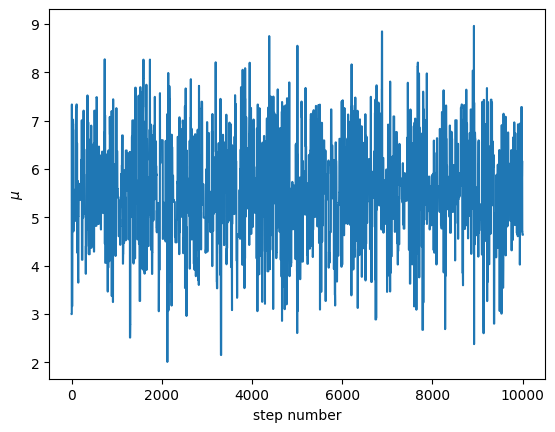

In [17]:
plt.plot(chain)
plt.xlabel('step number')
plt.ylabel(r'$\mu$')
plt.show()

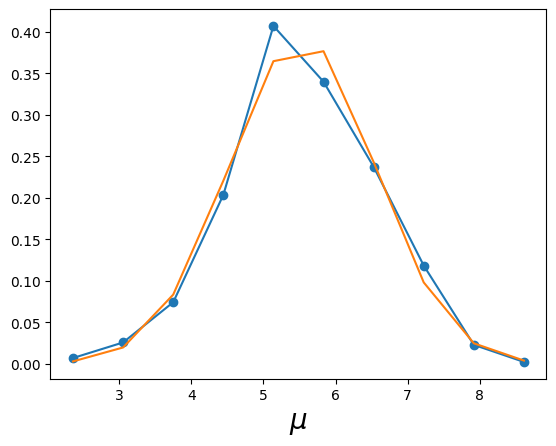

In [18]:
plt.plot(mu_vals,mu_hits,marker='o')
plt.plot(mu_vals,norm.pdf(mu_vals, mu_post_mean, mu_post_std))
plt.xlabel(r'$\mu$',fontsize=20)
plt.show()

Size of the data array = 100


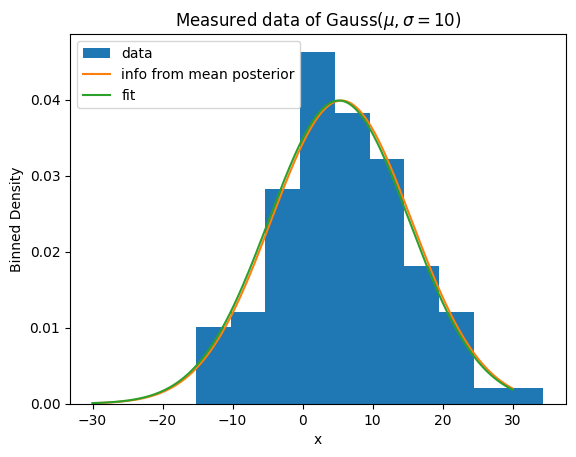

In [19]:
# Plot the data
sigma = 10.

print('Size of the data array = {}'.format(np.size(toy_data)))
plt.title(r"Measured data of Gauss$(\mu,\sigma=10)$")
plt.hist(toy_data,bins=10, density=True,label='data')


x = np.linspace(-30,30,1000)
plt.plot(x,stats.norm.pdf(x,np.mean(chain),10),label='info from mean posterior')
plt.plot(x,stats.norm.pdf(x,mu_fit,10),label='fit')
plt.legend()


plt.xlabel('x')
plt.ylabel('Binned Density')
plt.show()

### In this toy case of course we do not find much difference and the MCMC is a bit of an overkill. But what did we learn in a much more accurate way wrt the standard fit?

## Toy model for Approximate Bayesian Computation




* We would like to use ABC to find the 1D posterior distribution of $\mu$ given the observed data.


* We need to create a toy "simulator" (forward modelling)


* Use a uniform prior on $\mu$ = (-20, 20)


* Create a distance measure for the toy problem.


* Run the ABC and find a threshold for your designed distance measure. Calculate the "Acceptance Rate" - how many samples out of the prior were accepted by the threshold to the posterior?


### forward model: We draw N data point from a Gaussian with a given mu and sigma=10

In [20]:
#We scan mu inside the prior to generate M simulations
M=10**5
mu = np.random.uniform(low=-20.0, high=20.0, size=M)
samples = np.zeros((N,M))
for mm in range(int(M)):
    samples[:,mm]=stats.norm.rvs(loc=mu[mm], scale=sigma, size=N) #you could do directly size=(N,M)

In [21]:
#Now we need to define some distance (in priciple we do not have the likelihood!)

In [36]:
def abs_distance(sample):
    return np.abs(np.mean(toy_data)-np.mean(sample, axis=0))

def sq_distance(sample):
    return np.abs(np.mean(toy_data)-np.mean(sample, axis=0))**2





In [37]:
# compute the distance
dist = abs_distance(samples)
#choose a threshold
epsilon=1

Now that the ABC is run, we need to create some diagnostic plots:

 1. We plot the distance measure as a function of the $\mu$ for all the samples you generated.
    
 2. The number of samples which pass the threshold as a function of the threshold.
 3. We can also check the tightness of the constraint (standard deviation of the posterior on $\mu$) as a function of the threshold.

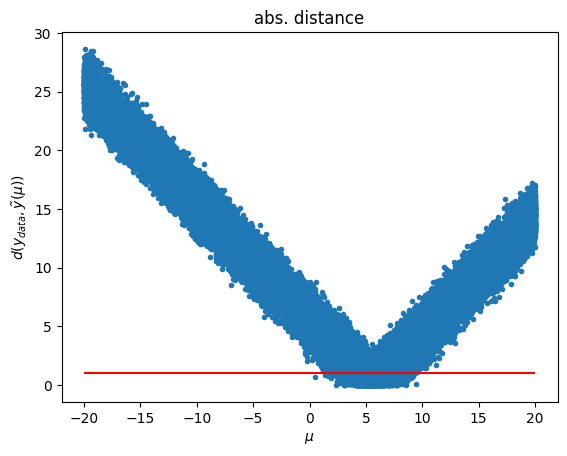

In [38]:
plt.title("abs. distance")
plt.plot(mu, dist, ".", zorder=1)
plt.hlines(epsilon, -20, 20, colors="red", zorder=2)
plt.xlabel(r'$\mu$')
plt.ylabel(r'$d(y_{data},\tilde{y}(\mu))$')
plt.show()

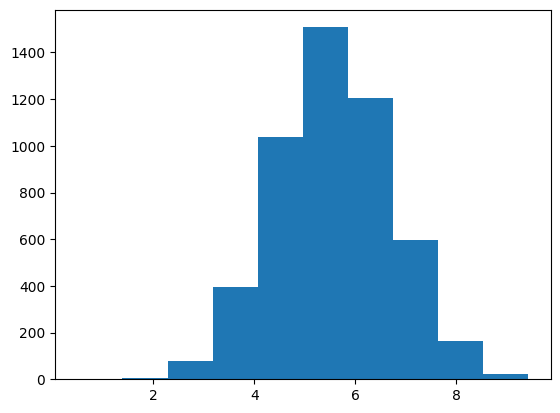

In [39]:
plt.hist(mu[np.where(dist<epsilon)])
plt.show()

In [40]:
# compute the distance
sq_dist = sq_distance(samples)
#choose a threshold
epsilon=0.5

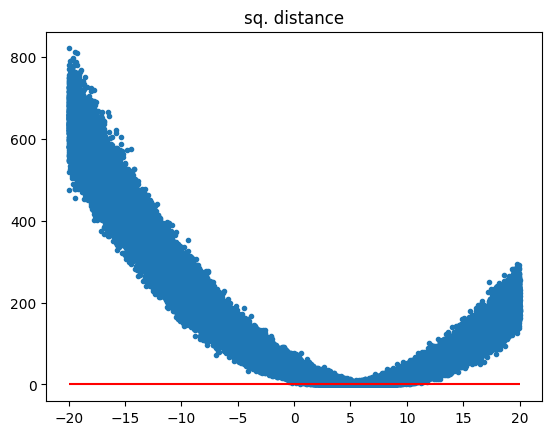

In [41]:
plt.figure()
plt.title("sq. distance")
plt.plot(mu, sq_dist, ".", zorder=1)
plt.hlines(epsilon, -20, 20, colors="red", zorder=2)

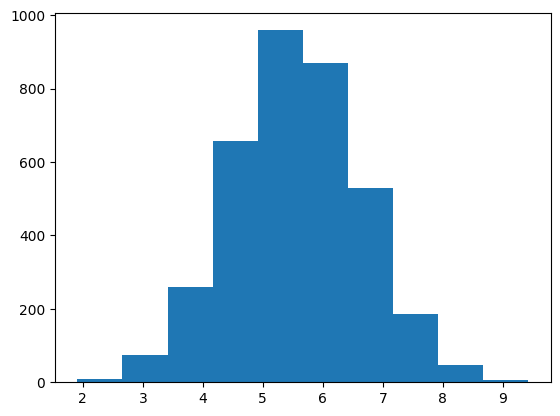

In [42]:
plt.hist(mu[np.where(sq_dist<epsilon)])
plt.show()

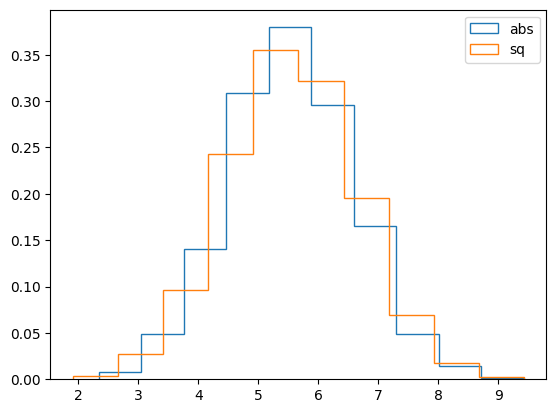

In [43]:
plt.hist(mu[np.where(dist<epsilon)],histtype='step',density=True,label='abs')
plt.hist(mu[np.where(sq_dist<epsilon)],histtype='step',density=True,label='sq')
plt.legend()
plt.show()

In [44]:
#let's check the other diagnostic plots for the abs distance and square

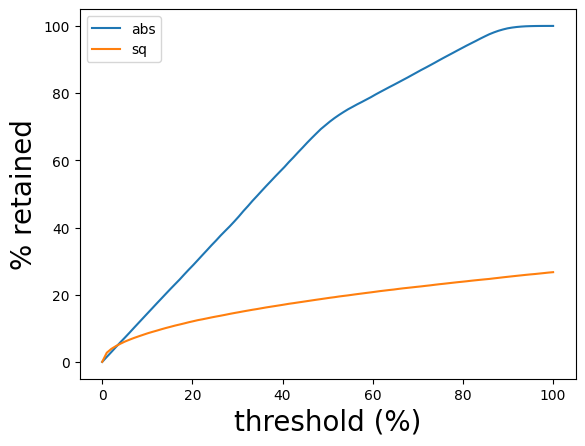

In [45]:
list_epsilon=np.linspace(np.min(dist),np.max(dist),100)
list_passed=[len(np.where(dist<epsilon)[0])/M*100 for epsilon in list_epsilon]

list_epsilon_sq=np.linspace(np.min(sq_dist),np.max(sq_dist),100)
list_passed_sq=[len(np.where(sq_dist<epsilon)[0])/M*100 for epsilon in list_epsilon]

plt.plot(list_epsilon/np.max(list_epsilon)*100,list_passed,label='abs')
plt.plot(list_epsilon_sq/np.max(list_epsilon_sq)*100,list_passed_sq,label='sq')
plt.xlabel('threshold (%)',fontsize=20)
plt.ylabel('% retained',fontsize=20)
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


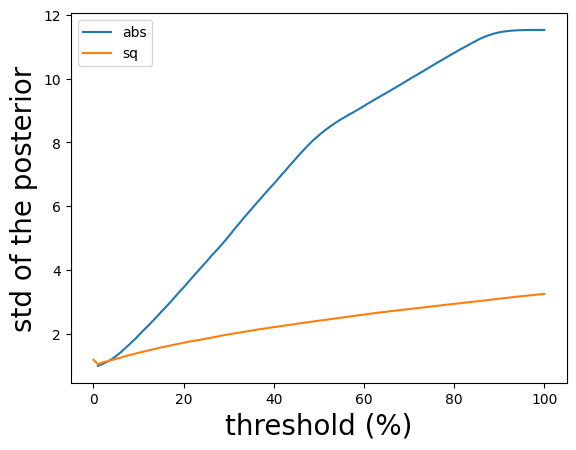

In [32]:
list_epsilon=np.linspace(np.min(dist),np.max(dist),100)
list_std=[np.std(mu[np.where(dist<epsilon)]) for epsilon in list_epsilon]

list_epsilon_sq=np.linspace(np.min(sq_dist),np.max(sq_dist),100)
list_std_sq=[np.std(mu[np.where(sq_dist<epsilon)]) for epsilon in list_epsilon]

plt.plot(list_epsilon/np.max(list_epsilon)*100,list_std,label='abs')
plt.plot(list_epsilon_sq/np.max(list_epsilon_sq)*100,list_std_sq,label='sq')
plt.xlabel('threshold (%)',fontsize=20)
plt.ylabel('std of the posterior',fontsize=20)
plt.legend()
plt.show()